# Components and mobility
This notebook examines trends in EFW component areas and movement across
quintiles to understand persistence and mobility in economic freedom.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import CLEAN_DIR, OUTPUT_DIR, QUINQUENNIAL_YEARS
from src.viz_style import savefig, set_style

In [2]:
set_style()
panel_path = CLEAN_DIR / "panel_quinquennial_atlas.parquet"
if not panel_path.exists():
    raise FileNotFoundError("Missing atlas panel. Run 03_build_quinquennial_panel first.")

panel = pd.read_parquet(panel_path)

,year,efw_area1,efw_area2,efw_area3,efw_area4,efw_area5
0,1970,6.408666,4.616190,7.331312,5.219133,5.709072
1,1975,5.735399,4.667921,5.944628,5.085706,5.447832
2,1980,5.345936,4.868478,6.056266,5.032977,5.526313
3,1985,5.371752,4.983355,6.232544,5.113578,5.822115
4,1990,5.669429,5.049615,6.335568,5.570100,5.861613
5,1995,6.193126,5.325519,6.488576,6.607476,5.863975
6,2000,6.286408,4.967477,6.737751,7.194885,6.023330
7,2005,6.566247,5.161785,7.288726,7.042194,6.149017
8,2010,6.494137,5.233515,7.553888,7.172585,6.213034
9,2015,6.627200,5.308919,7.964109,7.150345,6.302813


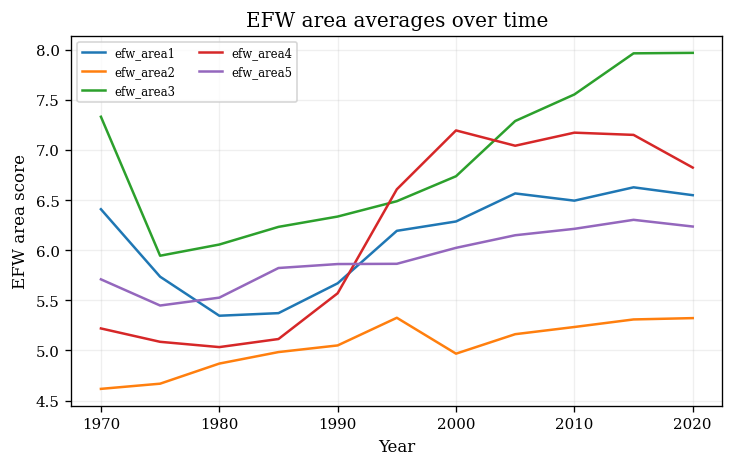

In [3]:
area_cols = [
    col
    for col in ["efw_area1", "efw_area2", "efw_area3", "efw_area4", "efw_area5"]
    if col in panel.columns
]
if area_cols:
    area_trends = panel.groupby("year")[area_cols].mean().reset_index()
    display(area_trends.style.set_caption("Average EFW area scores by year"))
    fig, ax = plt.subplots(figsize=(7, 4))
    for col in area_cols:
        ax.plot(area_trends["year"], area_trends[col], label=col)
    ax.set_title("EFW area averages over time")
    ax.set_xlabel("Year")
    ax.set_ylabel("EFW area score")
    ax.legend(fontsize=7, ncol=2)
    display(fig)
    savefig(fig, OUTPUT_DIR / "figures" / "components" / "efw_area_trends")
    plt.close(fig)

quintile_t5,1,2,3,4,5
quintile_t,,,,,
1,15,5,0,0,0
2,4,7,6,2,0
3,1,6,4,9,0
4,0,1,6,7,5
5,0,0,2,1,17


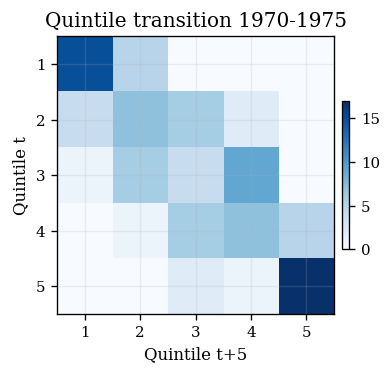

quintile_t5,1,2,3,4,5
quintile_t,,,,,
1,15,7,0,0,0
2,4,10,5,2,0
3,0,5,10,5,1
4,2,0,6,12,1
5,0,0,0,2,20


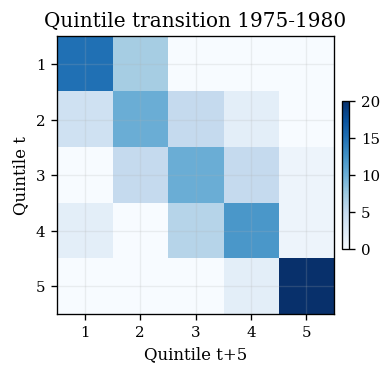

quintile_t5,1,2,3,4,5
quintile_t,,,,,
1,16,5,1,0,0
2,4,10,6,2,0
3,2,5,10,4,1
4,0,1,4,15,2
5,0,0,0,2,20


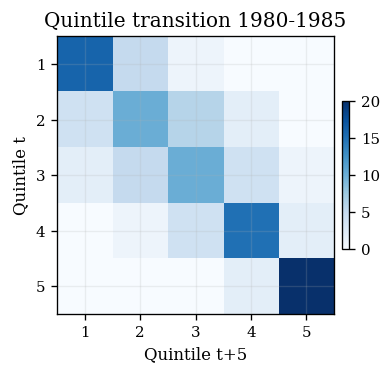

quintile_t5,1,2,3,4,5
quintile_t,,,,,
1,20,2,1,0,0
2,3,13,7,0,0
3,1,5,10,6,0
4,0,2,4,13,4
5,0,0,0,3,20


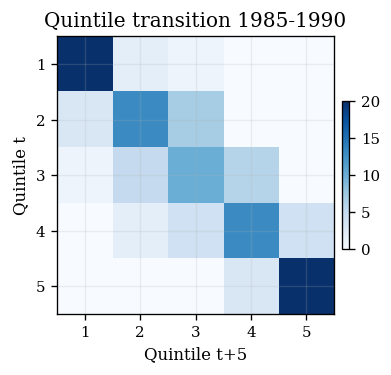

quintile_t5,1,2,3,4,5
quintile_t,,,,,
1,13,7,4,0,0
2,8,8,5,2,0
3,2,8,8,5,0
4,0,1,4,16,2
5,0,0,0,1,23


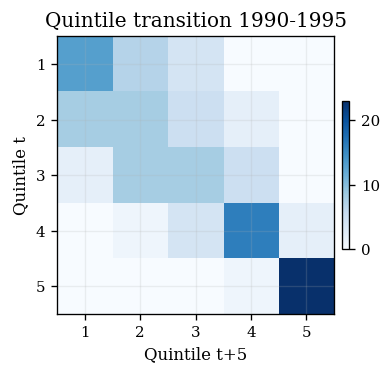

quintile_t5,1,2,3,4,5
quintile_t,,,,,
1,12,11,2,0,0
2,2,9,9,4,0
3,1,1,12,10,1
4,0,0,2,16,6
5,0,0,0,0,25


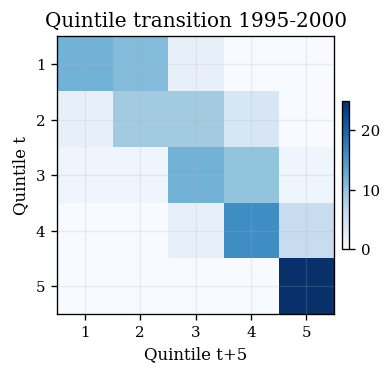

quintile_t5,1,2,3,4,5
quintile_t,,,,,
1,24,7,1,0,0
2,5,15,9,2,0
3,2,8,17,5,0
4,0,1,5,20,5
5,0,0,0,5,27


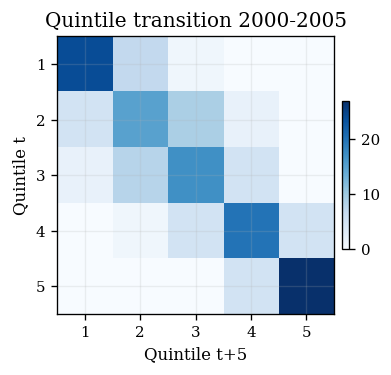

quintile_t5,1,2,3,4,5
quintile_t,,,,,
1,25,4,3,1,0
2,8,19,5,0,0
3,0,9,19,4,0
4,0,0,4,25,3
5,0,0,1,1,30


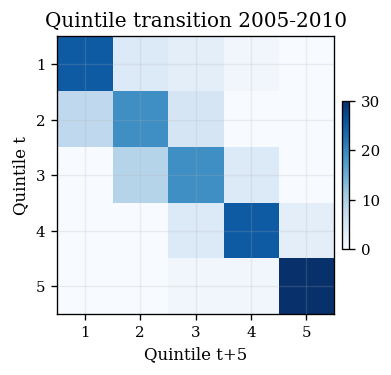

quintile_t5,1,2,3,4,5
quintile_t,,,,,
1,27,6,0,0,0
2,6,19,6,1,0
3,0,7,20,5,0
4,0,0,6,21,5
5,0,0,0,5,28


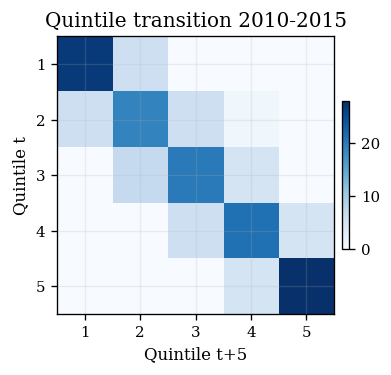

quintile_t5,1,2,3,4,5
quintile_t,,,,,
1,27,6,0,0,0
2,3,25,4,0,0
3,2,1,24,5,0
4,0,0,4,24,4
5,0,0,0,4,29


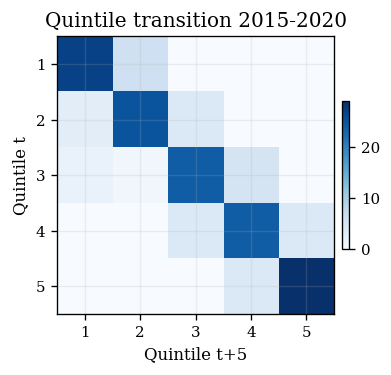

,window,stay_share,n
0,1970-1975,0.510204,98
1,1975-1980,0.626168,107
2,1980-1985,0.645455,110
3,1985-1990,0.666667,114
4,1990-1995,0.581197,117
5,1995-2000,0.601626,123
6,2000-2005,0.651899,158
7,2005-2010,0.732919,161
8,2010-2015,0.709877,162
9,2015-2020,0.796296,162


In [4]:
if "efw_summary" in panel.columns:
    panel = panel.copy()
    panel["quintile"] = panel.groupby("year")["efw_summary"].transform(
        lambda series: pd.qcut(series.rank(method="first"), 5, labels=False) + 1
    )

    transition_dir = OUTPUT_DIR / "tables" / "mobility_transition_matrices"
    transition_dir.mkdir(parents=True, exist_ok=True)
    fig_dir = OUTPUT_DIR / "figures" / "mobility"
    fig_dir.mkdir(parents=True, exist_ok=True)
    mobility_stats = []

    for year in QUINQUENNIAL_YEARS:
        next_year = year + 5
        if next_year not in QUINQUENNIAL_YEARS:
            continue
        left = panel[panel["year"] == year][["iso3c", "quintile"]]
        right = panel[panel["year"] == next_year][["iso3c", "quintile"]]
        merged = left.merge(right, on="iso3c", suffixes=("_t", "_t5"))
        if merged.empty:
            continue
        matrix = pd.crosstab(merged["quintile_t"], merged["quintile_t5"]).reindex(
            index=range(1, 6), columns=range(1, 6), fill_value=0
        )
        matrix.to_csv(transition_dir / f"transition_{year}_{next_year}.csv")
        display(matrix.style.set_caption(f"Transition matrix {year}-{next_year}"))
        stay_share = float(matrix.values.trace()) / float(matrix.values.sum())
        mobility_stats.append(
            {"window": f"{year}-{next_year}", "stay_share": stay_share, "n": int(matrix.values.sum())}
        )

        fig, ax = plt.subplots(figsize=(4, 3))
        img = ax.imshow(matrix, cmap="Blues")
        ax.set_title(f"Quintile transition {year}-{next_year}")
        ax.set_xlabel("Quintile t+5")
        ax.set_ylabel("Quintile t")
        ax.set_xticks(range(5))
        ax.set_yticks(range(5))
        ax.set_xticklabels(range(1, 6))
        ax.set_yticklabels(range(1, 6))
        fig.colorbar(img, ax=ax, fraction=0.02, pad=0.02)
        display(fig)
        savefig(fig, fig_dir / f"transition_{year}_{next_year}")
        plt.close(fig)

    if mobility_stats:
        mobility_df = pd.DataFrame(mobility_stats)
        display(mobility_df.style.set_caption("Quintile persistence by window"))

In [5]:
if "d5_efw_summary" in panel.columns:
    movers_dir = OUTPUT_DIR / "tables" / "mobility_movers"
    movers_dir.mkdir(parents=True, exist_ok=True)
    for year in QUINQUENNIAL_YEARS:
        subset = panel[panel["year"] == year][
            ["iso3c", "country_name", "d5_efw_summary"]
        ].dropna()
        if subset.empty:
            continue
        ranked = subset.sort_values("d5_efw_summary", ascending=False)
        movers = pd.concat([ranked.head(10), ranked.tail(10)])
        movers.to_csv(movers_dir / f"movers_{year}.csv", index=False)
        display(movers.style.set_caption(f"Top/bottom movers {year}"))

,iso3c,country_name,d5_efw_summary
1915,NPL,Nepal,1.060000
727,ECU,Ecuador,0.550000
1541,LUX,Luxembourg,0.540000
463,CMR,Cameroon,0.470000
1013,GTM,Guatemala,0.450000
1156,IDN,Indonesia,0.390000
2234,SEN,Senegal,0.350000
1046,HKG,"Hong Kong SAR, China",0.330000
1101,HUN,Hungary,0.280000
2410,SWE,Sweden,0.220000


,iso3c,country_name,d5_efw_summary
244,BHR,Bahrain,1.510000
2092,PRT,Portugal,1.170000
431,CHL,Chile,1.090000
893,GBR,United Kingdom,0.990000
651,DOM,Dominican Republic,0.970000
2191,RWA,Rwanda,0.810000
1916,NPL,Nepal,0.740000
101,ARG,Argentina,0.730000
1696,MLI,Mali,0.620000
409,CHE,Switzerland,0.620000


,iso3c,country_name,d5_efw_summary
1378,KWT,Kuwait,1.650000
1961,OMN,Oman,1.460000
1796,MUS,Mauritius,1.460000
2643,TUR,Turkiye,1.100000
2511,TGO,Togo,1.030000
894,GBR,United Kingdom,0.980000
1158,IDN,Indonesia,0.910000
1994,PAN,Panama,0.830000
2192,RWA,Rwanda,0.790000
883,GAB,Gabon,0.770000


,iso3c,country_name,d5_efw_summary
312,BOL,Bolivia,1.620000
433,CHL,Chile,1.520000
532,CRI,Costa Rica,1.470000
917,GHA,Ghana,1.390000
1236,ISL,Iceland,1.340000
1654,MEX,Mexico,1.150000
2017,PHL,Philippines,1.140000
202,BEN,Benin,1.070000
1940,NZL,New Zealand,1.040000
323,BRA,Brazil,1.040000


,iso3c,country_name,d5_efw_summary
1886,NIC,Nicaragua,2.850000
2689,UGA,Uganda,2.330000
104,ARG,Argentina,2.140000
2007,PER,Peru,2.100000
2282,SLV,El Salvador,2.020000
2678,TZA,Tanzania,1.690000
654,DOM,Dominican Republic,1.620000
2865,ZMB,Zambia,1.550000
2106,PRY,Paraguay,1.470000
2051,POL,Poland,1.380000


,iso3c,country_name,d5_efw_summary
787,EST,Estonia,1.680000
2195,RWA,Rwanda,1.300000
2008,PER,Peru,1.300000
1084,HRV,Croatia,1.300000
325,BRA,Brazil,1.290000
1557,LVA,Latvia,1.160000
2690,UGA,Uganda,1.140000
1876,NGA,Nigeria,1.130000
1535,LTU,Lithuania,1.130000
1623,MDG,Madagascar,1.080000


,iso3c,country_name,d5_efw_summary
117,ARM,Armenia,1.880000
2174,ROU,Romania,1.790000
1514,LSO,Lesotho,1.740000
1327,KGZ,Kyrgyz Republic,1.530000
238,BGR,Bulgaria,1.520000
1404,LAO,Lao PDR,1.380000
1745,MNE,Montenegro,1.230000
2317,SRB,Serbia,1.220000
1789,MRT,Mauritania,1.040000
293,BLZ,Belize,1.020000


,iso3c,country_name,d5_efw_summary
2164,QAT,Qatar,1.960000
2846,YEM,"Yemen, Rep.",1.750000
2538,TJK,Tajikistan,1.480000
954,GMB,"Gambia, The",1.420000
1416,LBN,Lebanon,1.320000
1229,IRQ,Iraq,1.320000
2879,ZWE,Zimbabwe,1.210000
2219,SAU,Saudi Arabia,1.210000
52,AGO,Angola,1.040000
283,BLR,Belarus,0.990000


,iso3c,country_name,d5_efw_summary
1725,MMR,Myanmar,1.340000
944,GIN,Guinea,1.020000
2880,ZWE,Zimbabwe,1.000000
2451,SYC,Seychelles,0.940000
2572,TLS,Timor-Leste,0.930000
1439,LBY,Libya,0.810000
1824,MYS,Malaysia,0.810000
911,GEO,Georgia,0.700000
1241,ISL,Iceland,0.690000
185,BDI,Burundi,0.670000


,iso3c,country_name,d5_efw_summary
285,BLR,Belarus,1.880000
1231,IRQ,Iraq,1.320000
945,GIN,Guinea,1.000000
2705,UKR,Ukraine,0.970000
2221,SAU,Saudi Arabia,0.770000
384,CAF,Central African Republic,0.580000
1726,MMR,Myanmar,0.440000
2793,VNM,Viet Nam,0.390000
1242,ISL,Iceland,0.380000
208,BEN,Benin,0.370000


## Interpretation
Component averages track the broad evolution of EFW sub-areas over time.
The transition matrices show substantial persistence: on average about 65%
of countries remain in the same quintile across five-year windows. The movers
tables identify countries with the most pronounced improvements or declines
in economic freedom.